In [1]:
%reload_ext autoreload
%autoreload 2
# %matplotlib qt
%matplotlib inline

from matplotlib import pyplot as plt
from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer
from vrAnalysis.helpers.plotting import save_figure
from dimensionality_manuscript.registry import PopulationRegistry, RegistryPaths
from dimensionality_manuscript import SubspaceConfig, StimSpaceSpectraConfig
from dimensionality_manuscript import ResultsAggregator, ResultsStore
from dimensionality_manuscript.configs import PlaceFieldStructureConfig
from dimensionality_manuscript.schematics.subspace import flow_schematic

# get session database
sessiondb = get_database("vrSessions")

# get population registry and models
registry = PopulationRegistry()
registry_paths = RegistryPaths()
figure_path = registry_paths.figure_path / "figure3"
if not figure_path.exists():
    figure_path.mkdir(parents=True, exist_ok=True)

In [2]:
# return_syd_viewer = False
# fig = flow_schematic("dim", return_syd_viewer=return_syd_viewer)
# if return_syd_viewer:
#     fig.show()
# else:
#     plt.show()

#     save = True
#     if save:
#         save_figure(fig, figure_path / "dim_pipeline")

findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmti10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


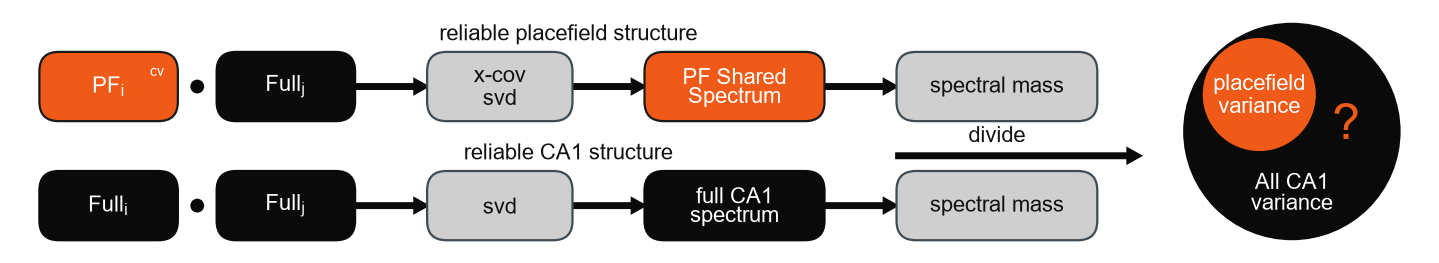

In [3]:
return_syd_viewer = False
fig = flow_schematic("svr", fig_width=7.0, return_syd_viewer=return_syd_viewer)
if return_syd_viewer:
    fig.show()
else:
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "svr_pipeline")

In [46]:
import numpy as np
from dimensionality_manuscript.schematics.subspace import VarianceWedgesViewer

viewer = VarianceWedgesViewer(
    num_wedges_pf_novel=7,
    num_wedges_pf_familiar=7,
    num_wedges_rest_novel=30,
    num_wedges_rest_familiar=30,
    pf_variance_novel=0.25,
    pf_variance_familiar=0.5,
    residual_variance_novel=0.6,
    residual_variance_familiar=0.6,
    wedge_gap=0.01,
    novel_title_text="Novel",
    familiar_title_text="Familiar",
    novel_title_x=0.25,
    novel_title_y=0.96,
    familiar_title_x=0.75,
    familiar_title_y=0.96,
    title_fontsize=8.0,
    start_angle=np.pi / 2,
    edge_linewidth=0.35,
    fig_width=2.5,
    fig_height=1.0,
    title_band=0.16,
    circle_scale=0.94,
)

return_syd_viewer = True
if return_syd_viewer:
    viewer.show()

else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "variance_wedges_figure")

In [2]:
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR")
store = ResultsStore()
cfg = StimSpaceSpectraConfig()
results = ResultsAggregator(cfg, store, sessions)
results_subspace = ResultsAggregator(SubspaceConfig, store, sessions)
results_pfstructure = ResultsAggregator(PlaceFieldStructureConfig, store, sessions)

c:\Users\Andrew\AppData\Local\miniforge3\envs\vrAnalysis\Lib\site-packages\syd\support.py:162: ParameterUpdateWarning: Warning updating FloatParameter parameter 'ax1_width_ratio': Value 0.15000000000000002 below minimum 0.2, clamping
  warn(ParameterUpdateWarning(parameter_name, parameter_type, message))
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure3\_familiarity.py:194: RuntimeWarning: invalid value encountered in divide
  ratio = np.nansum(sf, axis=1) / total
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure3\_ratios.py:206: RuntimeWarning: Mean of empty slice
  ax.plot(xvals(ff), np.nanmean(ff, axis=0), color=ff_color, label="Full CA1", linewidth=2.0)


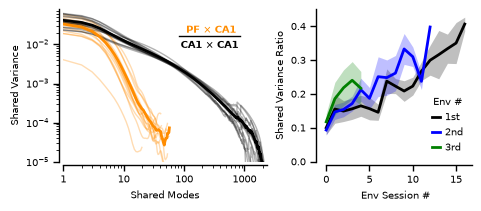

In [21]:
from dimensionality_manuscript.figure_scripts.figure3 import ConciseSpectrumViewer

viewer = ConciseSpectrumViewer(
    results,
    activity_parameters_name="std",
    within_condition=False,
    style_all="errorPlot",
    env_full_scope="within_env",
    spectrum_mode="avg_env",
    full_within_env=False,
    style_by_env="errorPlot",
    include="none",
    all_text_xy=(0.95, 0.1),
    all_text_ha="right",
    ax1_width_ratio=0.15,
    ax23_width_ratio=2/2.7,
    annotation_yoffset=-0.1,
    annotation_line_yoffset=0.012,
    annotation_line_xpad=0.15,
    spectrum_legend=dict(
        loc="lower left",
        handlelength=0.6,
        markerfirst=True,
        handletextpad=0.35,
        borderpad=0.0,
        borderaxespad=0.2,
        visible=False,
    ),
    env_legend=dict(
        loc="lower right",
    ),
    ylims=(-5.0, -1.1),
    shared_variance_ratio_ylims=(0.0, 0.45),
    figsize=(4.7, 2.0),
    show_slope_panel=False,
    fontsize=7.0,
)

return_syd_viewer = False
if return_syd_viewer:
    viewer.show()

else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "concise_spectrum_figure")


findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmti10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


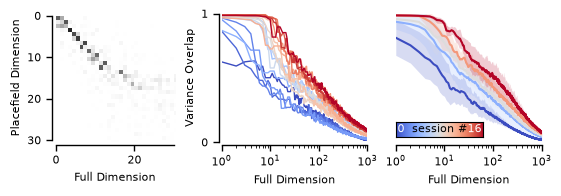

In [ ]:
from dimensionality_manuscript.figure_scripts.figure3 import SubspaceCrossspaceExampleViewer

return_syd_viewer = False
viewer = SubspaceCrossspaceExampleViewer(
    results_subspace,
    mouse="ATL049",
    idx_cross=1,
    num_cross_show=30,
    curve_mode="by_session",
    plot_style="errorPlot",
    skip_sessions=3,
    curve_smooth_kind="median",
    curve_smooth_width=5, 
    inset_x=0.0,
    inset_height=0.12,
    figsize=(5.5, 1.85),
    fontsize=8.0,
)

if return_syd_viewer:
    viewer.show()

else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "cross_space_analysis_with_example")


In [8]:
from dimensionality_manuscript.figure_scripts.figure3 import SubspaceCrossspaceViewer

return_syd_viewer = True
viewer = SubspaceCrossspaceViewer(
    results_subspace,
    idx_cross=2,
    plot_energy=True,
    num_cross_show=30,
    weighted=False,
    curve_mode="by_session",
    plot_style="errorPlot",
    hide_error=False,
    skip_sessions=3,
    curve_smooth_kind="median",
    curve_smooth_width=3,
    kink_threshold=0.975,
    max_arrow_x=1.2,
    max_arrow_y_start=0.7,
    max_arrow_y_end=0.965,
    kink_arrow_x_start=1.3,
    kink_arrow_x_end=6.0,
    kink_arrow_y=0.935,
    missing_structure_x_offset=10.0,
    missing_structure_y_offset=0.05,
    missing_structure_alpha=0.3,
    arrow_linewidth=1.75,
    arrow_head_size=0.25,
    figsize=(8.0, 2.2),
    fontsize=8.0,
)

if return_syd_viewer:
    viewer.show()

else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "cross_space_analysis")


C:\Users\Andrew\Documents\GitHub\vrAnalysis\vrAnalysis\helpers\plotting.py:144: RuntimeWarning: Mean of empty slice
  meanData = mean(data, axis=axis)
c:\Users\Andrew\AppData\Local\miniforge3\envs\vrAnalysis\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [9]:
from dimensionality_manuscript.figure_scripts.figure3 import SubspaceCrossPerMouseViewer

return_syd_viewer = True
plt.close('all')
viewer = SubspaceCrossPerMouseViewer(
    results_subspace,
    mouse="ATL049",
    session=14,
    num_cross_show=30,
    curve_smooth_kind="median",
    curve_smooth_width=5,
    kink_threshold=0.95,
    figsize=(8.0, 3.0),
)
if return_syd_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "crossspace_familiarity_example")


In [10]:
from dimensionality_manuscript.figure_scripts.figure3 import CompleteSpectrumViewer

return_syd_viewer = True
viewer = CompleteSpectrumViewer(
    results,
    within_condition=False,
    style_all="errorPlot",
    env_full_scope="within_env",
    full_within_env=False,
    style_by_env="errorPlot",
    within_xspace=0.5,
    between_xspace=0.5,
    ax1_width_ratio=0.75,
    ax23_width_ratio=0.75,
    spectrum_legend=dict(
        handlelength=1.0,
    ),
    figsize=(6.8, 2.25),
    show_slope_panel=False,
    fontsize=8.0,
)

if return_syd_viewer:
    viewer.show()

else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "complete_spectrum_figure")


C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure3\_familiarity.py:164: RuntimeWarning: invalid value encountered in divide
  ratio = np.nansum(sf, axis=1) / total


C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure3\_ratios.py:171: RuntimeWarning: Mean of empty slice
  ax.set_yticks(yticks, labels=ytick_power, fontsize=fontsize)


In [12]:
from dimensionality_manuscript.figure_scripts.figure3 import SubspaceCurvesRatiosViewer

return_syd_viewer = True
viewer = SubspaceCurvesRatiosViewer(
    results,
    figsize=(5.5, 3.0),
)

if return_syd_viewer:
    viewer.show()

else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = False
    if save:
        save_figure(fig, figure_path / "subspace_curves_ratios")


C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)


C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure3\_ratios.py:118: RuntimeWarning: Mean of empty slice
  ax.plot(xvals(ff), np.nanmean(ff, axis=0), color=ff_color, label="Reliable CA1", linewidth=2.0)


In [16]:
from dimensionality_manuscript.figure_scripts.figure3 import SubspaceFamiliarityViewer

return_syd_viewer = True
viewer = SubspaceFamiliarityViewer(
    results,
    plot_mode="all",
    env_full_scope="within_env",
    full_within_env=False,
    within_condition=False,
    style="errorPlot",
    figsize=(5.0, 3.0),
)

if return_syd_viewer:
    viewer.show()

else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = False
    if save:
        save_figure(fig, figure_path / "svr_over_familiarity")

In [ ]:
return_syd_viewer = True
viewer = SubspaceFamiliarityViewer(
    results,
    plot_mode="by_env",
    env_full_scope="within_env",
    full_within_env=False,
    style="errorPlot",
    figsize=(5.0, 3.0),
)

if return_syd_viewer:
    viewer.show()

else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "svr_over_familiarity_by_env")
